﷽

### Neural Nightingale: Avian Species Identification via Transfer Learning 🐦

This is my **Neural Nightingale** project. Telling different birds apart is surprisingly tough, especially when two species might have almost the exact same body shape and size, but completely different beak colors or feather patterns. In this project, we train an artificial intelligence model to look at photos of birds and tell us which species it is seeing. Instead of starting from scratch, we use transfer learning: we take a computer vision model **ResNet-34** that already knows how to see basic shapes and textures from millions of everyday photos, and we teach it specifically how to spot the details of our chosen bird species.

By the end of this notebook, our model will be able to take an image of a bird and output its top guesses along with confidence percentages, ready to be saved and turned into an interactive web app!

#### Before we begin, we will confirm that the GPU is working

In [2]:
import torch, torchvision
print("Pytorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Pytorch: 2.11.0+cu130 | torchvision: 0.26.0+cu130
GPU available: True
GPU: Tesla T4


#### Download and Extract the Dataset

The dataset we will be using is the CUB-200-2011 (Caltech-UCSD Birds) dataset. It has 200 categories and 11,788 images and covers North American bird species.

In [3]:
!wget -q --show-progress -O CUB_200_2011.tgz "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1"
!tar -xzf CUB_200_2011.tgz
!ls CUB_200_2011

CUB_200_2011.tgz    100%[===================>]   1.07G   190MB/s    in 5.0s    
attributes	    image_class_labels.txt  parts
bounding_boxes.txt  images		    README
classes.txt	    images.txt		    train_test_split.txt


#### Understanding the Raw data
Now I will be taking a further look at what I just downloaded, so that I can start understanding the raw data

In [4]:
from pathlib import Path
ROOT  = Path("CUB_200_2011")
classes = sorted(p.name for p in (ROOT / "images").iterdir())
print(len(classes), "species\n")
print("\n".join(classes))

200 species

001.Black_footed_Albatross
002.Laysan_Albatross
003.Sooty_Albatross
004.Groove_billed_Ani
005.Crested_Auklet
006.Least_Auklet
007.Parakeet_Auklet
008.Rhinoceros_Auklet
009.Brewer_Blackbird
010.Red_winged_Blackbird
011.Rusty_Blackbird
012.Yellow_headed_Blackbird
013.Bobolink
014.Indigo_Bunting
015.Lazuli_Bunting
016.Painted_Bunting
017.Cardinal
018.Spotted_Catbird
019.Gray_Catbird
020.Yellow_breasted_Chat
021.Eastern_Towhee
022.Chuck_will_Widow
023.Brandt_Cormorant
024.Red_faced_Cormorant
025.Pelagic_Cormorant
026.Bronzed_Cowbird
027.Shiny_Cowbird
028.Brown_Creeper
029.American_Crow
030.Fish_Crow
031.Black_billed_Cuckoo
032.Mangrove_Cuckoo
033.Yellow_billed_Cuckoo
034.Gray_crowned_Rosy_Finch
035.Purple_Finch
036.Northern_Flicker
037.Acadian_Flycatcher
038.Great_Crested_Flycatcher
039.Least_Flycatcher
040.Olive_sided_Flycatcher
041.Scissor_tailed_Flycatcher
042.Vermilion_Flycatcher
043.Yellow_bellied_Flycatcher
044.Frigatebird
045.Northern_Fulmar
046.Gadwall
047.American_Gol

#### Creating a 15 Species Subset

This snippet filters our full dataset for a specific target list of 15 bird species. Because the dataset folder names start with numbers like 017.Cardinal, the code splits each name at the dot to isolate just the species name. It then filters the dataset to keep only folders matching our wanted list, and uses set subtraction to instantly flag any species that weren't found so we can catch spelling mismatches.

In [5]:
WANTED = ["Cardinal", "Blue_Jay", "American_Goldfinch", "Red_winged_Blackbird", "Mallard",
          "American_Crow", "Downy_Woodpecker", "Pileated_Woodpecker", "Ruby_throated_Hummingbird",
          "Baltimore_Oriole", "Brown_Pelican", "Northern_Flicker", "Indigo_Bunting",
          "House_Sparrow", "Common_Yellowthroat"]

selected = [c for c in classes if c.split(".", 1)[1] in WANTED]
found = {c.split(".", 1)[1] for c in selected}
print(f"Matched {len(selected)} of {len(WANTED)}")
print("Not found (check spelling against list above):", set(WANTED) - found)

Matched 15 of 15
Not found (check spelling against list above): set()


#### Splitting the Images
This code parses the dataset's metadata files to figure out which images belong to our selected species and whether each image is flagged for training or testing. It creates a fresh data/ directory, copies all training images into data/train/<SpeciesName>/, and takes the official test images and randomly splits them 50/50 into val and test subdirectories. Finally, it counts the files in each directory to verify that the dataset split was successful

In [6]:
from prompt_toolkit.styles import named_colors
import shutil, random
from collections import defaultdict

id_to_path = dict(line.split() for line in open(ROOT / "images.txt"))
id_is_train = {i: flag == "1" for i, flag in (line.split() for line in open(ROOT / "train_test_split.txt"))}

DATA = Path("data")
if DATA.exists():
  shutil.rmtree(DATA)

random.seed(42) # for reproducibility
held_out = defaultdict(list)

for img_id, rel_path in id_to_path.items():
  species_folder = rel_path.split("/")[0]
  if species_folder not in selected:
    continue
  name = species_folder.split(".", 1)[1] # "017.Cardinal" --> "Cardinal"
  src = ROOT / "images" / rel_path
  if id_is_train[img_id]:
    dst = DATA / "train" / name
    dst.mkdir(parents=True, exist_ok=True)
    shutil.copy(src, dst / src.name)
  else:
    held_out[name].append(src)

# Now we will split the test images 50/50 into the validation set and test set :)
for name, files in held_out.items():
  random.shuffle(files)
  half = len(files) // 2
  for split, chunk in [("val", files[:half]), ("test", files[half:])]:
    dst = DATA / split / name
    dst.mkdir(parents=True, exist_ok=True)
    for src in chunk:
      shutil.copy(src, dst / src.name)

for split in ["train", "val", "test"]:
  n = sum(len(list(d.iterdir())) for d in (DATA / split).iterdir())
  print(f"{split:5s}: {n} images")



train: 450 images
val  : 223 images
test : 224 images


#### Visualising the Data
This script visualizes our dataset by creating a 3x5 image grid using Matplotlib. It flattens the grid boxes into a 1D sequence and pairs each box with one of our 15 chosen species folders. For each species, it picks a random sample photo, loads it using PIL, removes the coordinate axes, adds a clean title with spaces instead of underscores, and displays the full grid so we can inspect sample images across all classes.


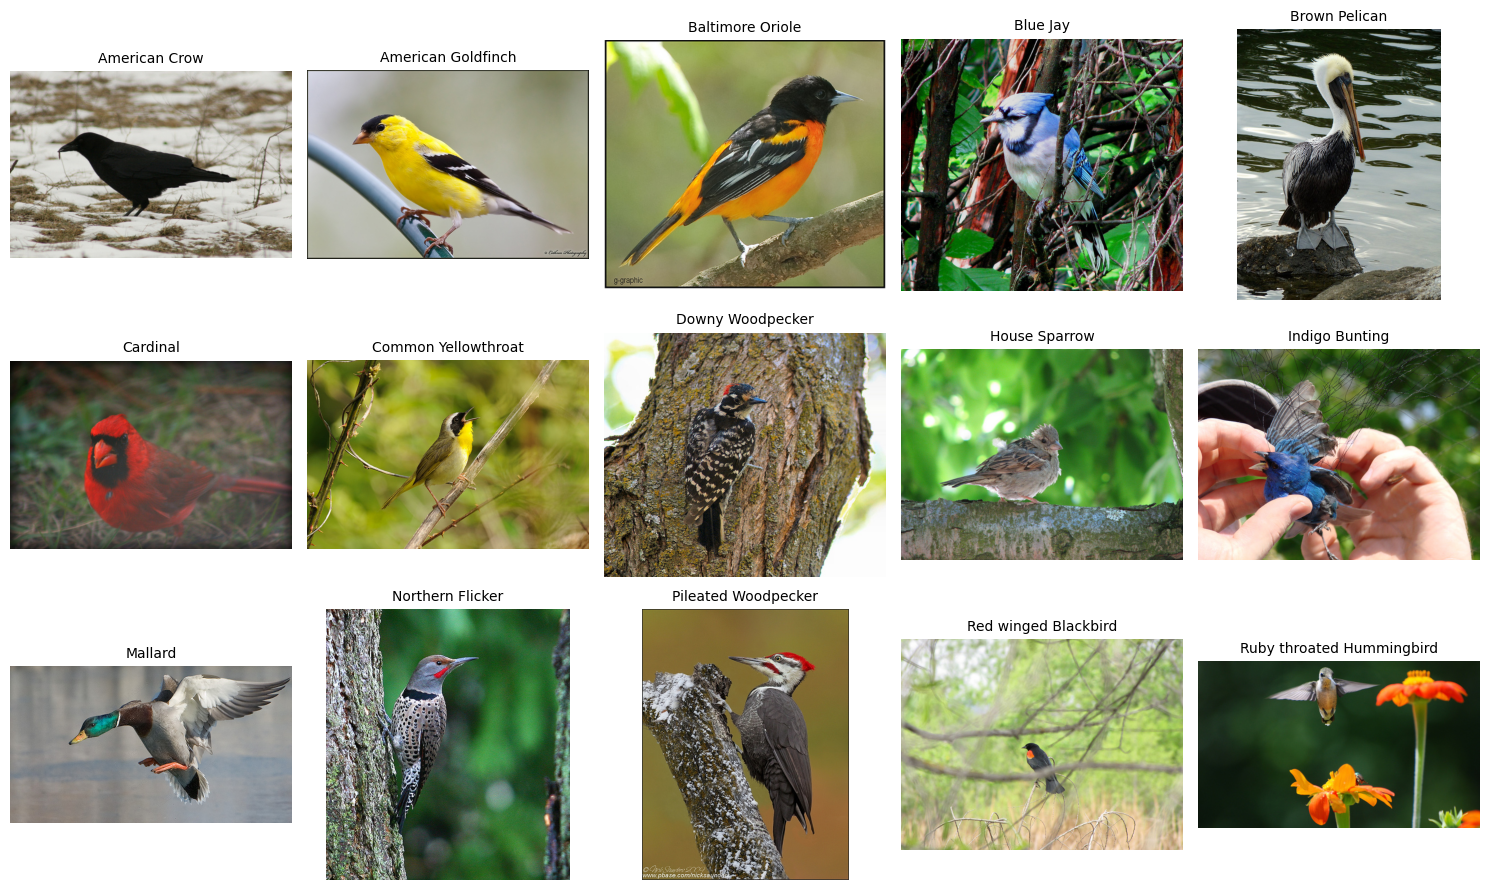

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, sp in zip(axes.flat, sorted((DATA / "train").iterdir())):
    img = Image.open(random.choice(list(sp.iterdir())))
    ax.imshow(img); ax.set_title(sp.name.replace("_", " "), fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

#### Data Preprocessing
This code sets up our preprocessing pipelines using torchvision.transforms. For the training set, we use data augmentation for random crops, horizontal flips, and color jitter, so the network sees different variations of our birds every epoch to prevent overfitting.

For validation and testing, we use fixed, deterministic resizing and center-cropping so test evaluations remain consistent. Both pipelines convert the images into PyTorch tensors and normalize them using ImageNet mean and standard deviation so they are ready for transfer learning.

In [9]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# Training -> random changes, so model sees slightly different version of birds every epoch
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale = (0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation/test -> same processing each time, so we don't have random variables on the test data
eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

#### Data Ingestion Pipeline for PyTorch
This code sets up our data ingestion pipeline in PyTorch. First, ImageFolder reads the images from disk, applies our transforms, and automatically assigns numerical label IDs based on the subfolder names. We run an assertion check to guarantee that our train, validation, and test sets all share the exact same class ordering. Finally, we wrap each dataset in a DataLoader to feed images to the model in batches of 32, enabling shuffling for training to vary mini-batches, and using two worker processes to speed up image loading

In [10]:
train_ds = datasets.ImageFolder(DATA / "train", transform=train_tfms)
val_ds   = datasets.ImageFolder(DATA / "val",   transform=eval_tfms)
test_ds  = datasets.ImageFolder(DATA / "test",  transform=eval_tfms)

class_names = train_ds.classes
assert class_names == val_ds.classes == test_ds.classes, "Class order mismatch!"
print(len(class_names), "classes")
print(train_ds.class_to_idx)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


15 classes
{'American_Crow': 0, 'American_Goldfinch': 1, 'Baltimore_Oriole': 2, 'Blue_Jay': 3, 'Brown_Pelican': 4, 'Cardinal': 5, 'Common_Yellowthroat': 6, 'Downy_Woodpecker': 7, 'House_Sparrow': 8, 'Indigo_Bunting': 9, 'Mallard': 10, 'Northern_Flicker': 11, 'Pileated_Woodpecker': 12, 'Red_winged_Blackbird': 13, 'Ruby_throated_Hummingbird': 14}


#### Inspecting one of the batches
This snippet pulls the first batch of 32 images and labels from our training DataLoader using next(iter(...)) to inspect their shapes and values. It verifies that our images are formatted as 4D PyTorch tensors of shape 32-by-3-by-224-by-224 with 32-bit float precision, checks that our labels are shuffled integers, and verifies that our pixel values are properly zero-centered and scaled via ImageNet normalization



In [11]:
images, labels = next(iter(train_loader))
print("images:", images.shape, images.dtype)
print("labels:", labels.shape, labels[:10])
print(f"pixel range after normalizing: {images.min():.2f} to {images.max():.2f}")

images: torch.Size([32, 3, 224, 224]) torch.float32
labels: torch.Size([32]) tensor([10, 11,  8, 10, 11,  9,  9,  2,  1, 10])
pixel range after normalizing: -2.12 to 2.64


#### Visualising the Data Augments
This snippet visualizes data augmentation on a single training example. We retrieve the exact same image index 8 times from our training dataset; because the dataset applies random transforms on each access, every call yields a distinct variation with different zooms, horizontal flips, and lighting conditions. We use a helper function to reverse the ImageNet normalization and rearrange the tensor axes from PyTorch's channel-first format to Matplotlib's channel-last format, displaying all 8 augmented views side-by-side

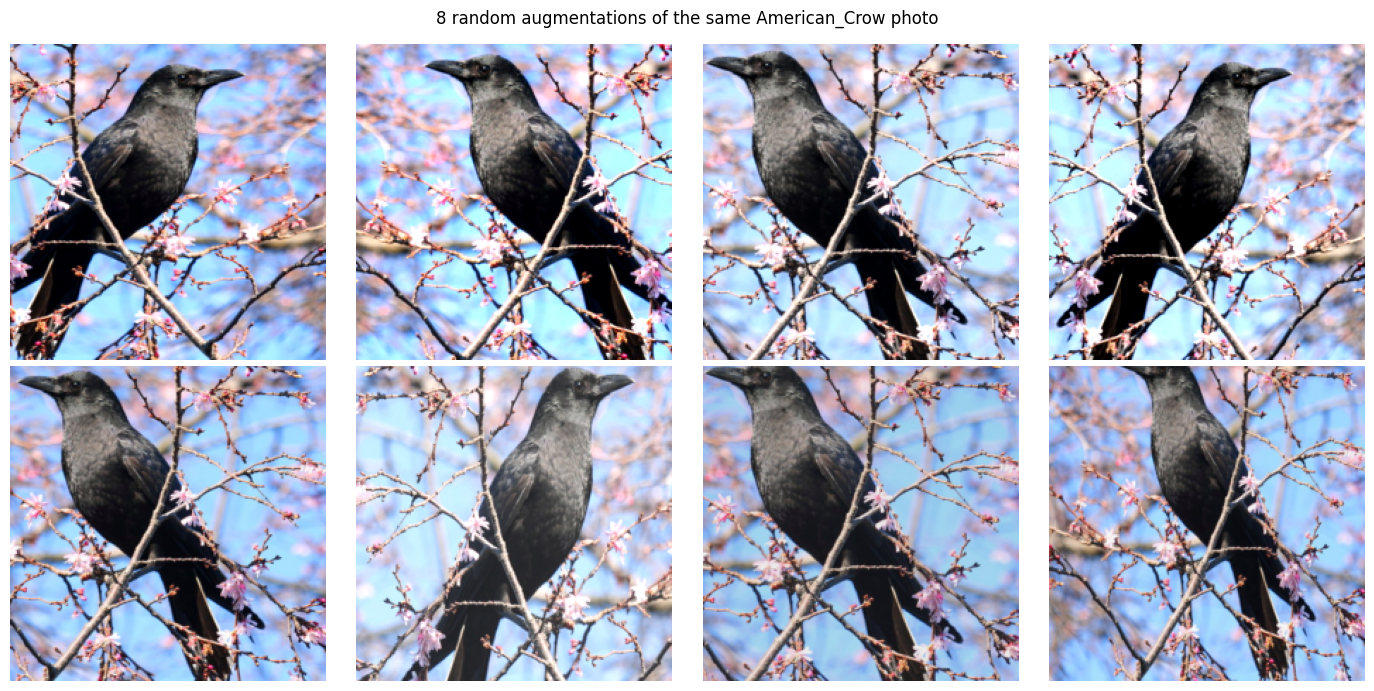

In [12]:
import torch
import matplotlib.pyplot as plt

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def to_displayable(t):
    # Undo Normalize and reorder to height × width × color so that matplotlib can show it
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0)

idx = 0  # try different numbers
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.flat:
    img, label = train_ds[idx]      # the random transforms run again on every call
    ax.imshow(to_displayable(img)); ax.axis("off")
fig.suptitle(f"8 random augmentations of the same {class_names[label]} photo")
plt.tight_layout(); plt.show()

#### Downloading The Res-Net 18 Neural Network
This snippet initializes our model for transfer learning. First, it dynamically selects a GPU (cuda) if available, or falls back to CPU. Next, it downloads a pre-trained ResNet-18 model with weights learned on ImageNet so we can take advantage of feature extraction. Finally, it iterates through the network's top-level layers to inspect its architecture and checks the final fully connected classification layer (fc), which currently outputs 1,000 classes and will need to be replaced to match our 15 bird classes

In [14]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for name, child in model.named_children():
  print(f"{name:8s} -> {child.__class__.__name__}")

print("\nFinal Layer:", model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 95.0MB/s]


conv1    -> Conv2d
bn1      -> BatchNorm2d
relu     -> ReLU
maxpool  -> MaxPool2d
layer1   -> Sequential
layer2   -> Sequential
layer3   -> Sequential
layer4   -> Sequential
avgpool  -> AdaptiveAvgPool2d
fc       -> Linear

Final Layer: Linear(in_features=512, out_features=1000, bias=True)


#### Layer Freezing and Classifier Replacement
In this step, we freeze all pre-existing ResNet-18 parameters by setting requires_grad = False so their pre-trained ImageNet weights won't be altered. Then, we replace the final classification layer with a new nn.Linear layer that maps the 512 extracted features to our 15 bird classes. Because the new layer defaults to requires_grad = True, backpropagation will only update those ~7,700 weights in the classifier head rather than all 11 million parameters in the backbone, allowing fast training without destroying the pre-learned visual filters

In [17]:
# 1) Freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2) Replace the final layer
model.fc = nn.Linear(model.fc.in_features, len(class_names))

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} of {total:,}")

Trainable parameters: 7,695 of 11,184,207


#### Choosing the loss function and optimizer
This snippet sets up our loss function and optimizer for training. We use CrossEntropyLoss as our criterion to evaluate how far off our predicted class probabilities are from the true bird labels. For the optimizer, we use Adam with a standard learning rate of 0.001. Importantly, we pass only model.fc.parameters() to the optimizer so that updates are confined entirely to our new classification head while the pre-trained backbone remains frozen.

It defines two mathematical engines that are required to train any neural network:

**The Judge** (criterion): Measures how wrong the model's predictions are compared to actual bird labels.

**The Mechanic** (optimizer): Uses the error score to calculate how to adjust the weights in model.fc so predictions improve on the next attempt.

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

#### Training and Evaluation Functions
This code sets up our training and evaluation functions. train_one_epoch runs through the standard five-step PyTorch training cycle: zeroing out previous gradients, performing a forward pass, computing cross-entropy loss, executing backpropagation via loss.backward(), and updating our classifier head weights with optimizer.step().

In contrast, evaluate sets the model to evaluation mode (model.eval()) and disables gradient tracking using @torch.no_grad() to compute loss and accuracy on our validation or test sets quickly without altering any parameters

In [21]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()              # 1. clear old gradients
        outputs = model(images)            # 2. forward pass
        loss = criterion(outputs, labels)  # 3. measures how wrong we were
        loss.backward()                    # 4. backpropagation (compute gradients)
        optimizer.step()                   # 5. update the weights

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += images.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += images.size(0)
    return total_loss / n, correct / n

#### Training
This cell contains the 8 epoch training loop. In each epoch, it calls train_one_epoch to update our classifier weights and evaluate on our validation loader to track generalization. It logs all loss and accuracy values into a history dictionary for plotting and tracks execution time per epoch. Crucially, it monitors validation accuracy and uses copy.deepcopy(model.state_dict()) to save an exact snapshot of the best model weights, ensuring that even if later epochs begin to overfit, we still have a checkpoint that had the most optimal results.

In [22]:
import copy, time

EPOCHS = 8
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
    va_loss, va_acc = evaluate(model, val_loader)
    for key, val in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
        history[key].append(val)

    if va_acc > best_acc:
        best_acc, best_state = va_acc, copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:2d} | train loss {tr_loss:.3f} acc {tr_acc:.1%} | "
          f"val loss {va_loss:.3f} acc {va_acc:.1%} | {time.time() - start:.0f}s")

print(f"\nBest validation accuracy: {best_acc:.1%}")

Epoch  1 | train loss 2.533 acc 21.8% | val loss 2.081 acc 46.2% | 6s
Epoch  2 | train loss 1.827 acc 53.8% | val loss 1.552 acc 71.7% | 6s
Epoch  3 | train loss 1.376 acc 78.9% | val loss 1.200 acc 84.3% | 4s
Epoch  4 | train loss 1.049 acc 83.8% | val loss 0.985 acc 87.4% | 5s
Epoch  5 | train loss 0.856 acc 88.7% | val loss 0.802 acc 86.5% | 5s
Epoch  6 | train loss 0.730 acc 89.8% | val loss 0.688 acc 91.0% | 4s
Epoch  7 | train loss 0.633 acc 91.6% | val loss 0.647 acc 91.5% | 5s
Epoch  8 | train loss 0.565 acc 91.3% | val loss 0.591 acc 90.1% | 5s

Best validation accuracy: 91.5%


#### Saving to Google Drive

In [24]:
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = Path("/content/drive/MyDrive/neural_nightingale")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
torch.save({"state_dict": best_state, "class_names": class_names},
           SAVE_DIR / "model_head_only.pth")
print("Saved to", SAVE_DIR)

Mounted at /content/drive
Saved to /content/drive/MyDrive/neural_nightingale


#### Plotting the Clearning curves
This snippet visualizes our training progress by plotting side-by-side learning curves using Matplotlib. The left panel shows training and validation loss per epoch, while the right panel displays training and validation accuracy. Plotting both sets together allows us to verify that our model is converging and monitor for signs of overfitting or plateauing across our 8 epochs.

For the loss function, we see that both are going downwards, which means that the model is learning.

An interesting sign to keep in mind is that, when train loss continues to fall while the validation loss curve has flattened or risen, means that **overfitting** has started.

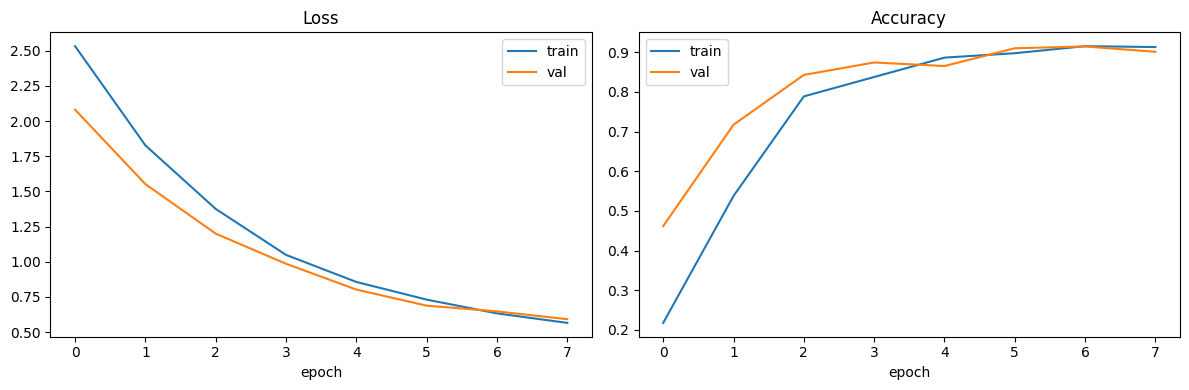

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()

#### Reflections

We see that accuracy dips at epoch 8 slightly, even though the loss improved.

**Accuracy** only checks whether the top guess is correct

**Loss** also measures how confident the model was in the correct answer

From epoch 7 to 8, the model got more confident overall (loss dropped), but only a few borderline images flipped to the wrong guess. Since our validation set had 223 images, one image equals 0.45%. The drop from 91.5% to 90.1% accuracy is just 3 images. The standar error of an accuracy estimate is √(p(1−p)/n) = √(0.9 × 0.1 / 223) ≈ 2 points. So epochs 6, 7, and 8 are statistically indistinguishible. This will likely impact our next step as well. If fine-tuning gains only 1 point, we might not be able to say confidently that it actually helped.

Also, a loss of 0,59 means the model's probability for the correct bird is about e^(-0.59) which is approx. 55%. It is usually right, but not confident.

#### Fine-tuning
This snippet transitions our training into fine-tuning. First, model.load_state_dict(best_state) restores the weights from our top-performing validation epoch. Then, we unfreeze ResNet's final convolutional stage, layer4, by setting its parameters' requires_grad to True. This increases our trainable parameter count from ~7,700 up to ~8.4 million, allowing the network to adapt its high-level visual feature representations specifically to bird morphology while keeping earlier, low-level edge-detecting layers frozen.

To account for layer4's well-tunes ImageNet features, we will need to adjust our learning rate from before so that there isn't forgetting (messing up pre-learned visual filters).

In [27]:
# If Colab disconnects after training, reload checkpoint first
# checkpoint = torch.load(SAVE_DIR / "model_head_only.pth")
# best_state, class_names = checkpoint["state_dict"], checkpoint["class_names"]

model.load_state_dict(best_state)   # go back to epoch 7 weights

for p in model.layer4.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,} of {total:,}")

Trainable parameters: 8,401,423 of 11,184,207


#### Assigning different learning rates
This snippet sets up differential learning rates for fine-tuning using PyTorch parameter groups in the Adam optimizer. We assign a smaller learning rate of 10^-4 to layer4 so its pre-trained visual representations are delicately adapted to bird features without destroying the weights learned on ImageNet.

Meanwhile, we maintain a higher learning rate of 10^-3 on the custom classification head (fc) so it can continue making faster updates to map those features to our 15 classes

In [29]:
optimizer_ft = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},   # small steps: refine, don't overwrite
    {"params": model.fc.parameters(),     "lr": 1e-3},   # head keeps its normal rate
])

#### Creating a training function
This cell puts our training and validation loop into a fit function. It takes the model, optimizer, and epoch count, logs lossa nd accuracy per eopch, and prints progess whenever new best validation accuracy is reached.

In [31]:
def fit(model, optimizer, epochs, best_acc=0.0, best_state=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        start = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, val_loader)
        for key, val in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
            history[key].append(val)
        marker = ""
        if va_acc > best_acc:
            best_acc, best_state = va_acc, copy.deepcopy(model.state_dict())
            marker = "  <- new best"
        print(f"Epoch {epoch:2d} | train loss {tr_loss:.3f} acc {tr_acc:.1%} | "
              f"val loss {va_loss:.3f} acc {va_acc:.1%} | {time.time() - start:.0f}s{marker}")
    return history, best_acc, best_state

#### Fine-tuning pt. 2
This snippet executes Stage 2 of transfer learning by fine-tuning layer4 and the classification head across 8 epochs using our differential optimizer. It passes the best validation accuracy and weights from Stage 1 into fit so that checkpoints are only updated if fine-tuning yields a higher score. Finally, if the fine-tuned model exceeds the head-only benchmark, it bundles both the optimal weights and the class_names list into a dictionary and saves it to disk as a .pth file, ensuring everything required for inference and deployment is preserved

In [32]:
head_best_acc = best_acc
history_ft, best_acc, best_state = fit(model, optimizer_ft, epochs=8,
                                       best_acc=best_acc, best_state=best_state)

print(f"\nHead only: {head_best_acc:.1%}  ->  after fine-tuning: {best_acc:.1%}")
if best_acc > head_best_acc:
    torch.save({"state_dict": best_state, "class_names": class_names},
               SAVE_DIR / "model_finetuned.pth")
    print("Saved fine-tuned model to Drive")

Epoch  1 | train loss 0.459 acc 91.6% | val loss 0.290 acc 93.3% | 6s  <- new best
Epoch  2 | train loss 0.150 acc 98.2% | val loss 0.195 acc 95.1% | 4s  <- new best
Epoch  3 | train loss 0.074 acc 99.8% | val loss 0.183 acc 95.5% | 4s  <- new best
Epoch  4 | train loss 0.064 acc 99.3% | val loss 0.200 acc 95.1% | 6s
Epoch  5 | train loss 0.043 acc 99.8% | val loss 0.187 acc 95.1% | 4s
Epoch  6 | train loss 0.046 acc 99.6% | val loss 0.181 acc 94.6% | 4s
Epoch  7 | train loss 0.034 acc 99.8% | val loss 0.172 acc 94.2% | 6s
Epoch  8 | train loss 0.039 acc 99.3% | val loss 0.218 acc 93.3% | 4s

Head only: 91.5%  ->  after fine-tuning: 95.5%
Saved fine-tuned model to Drive


#### Plotting the results

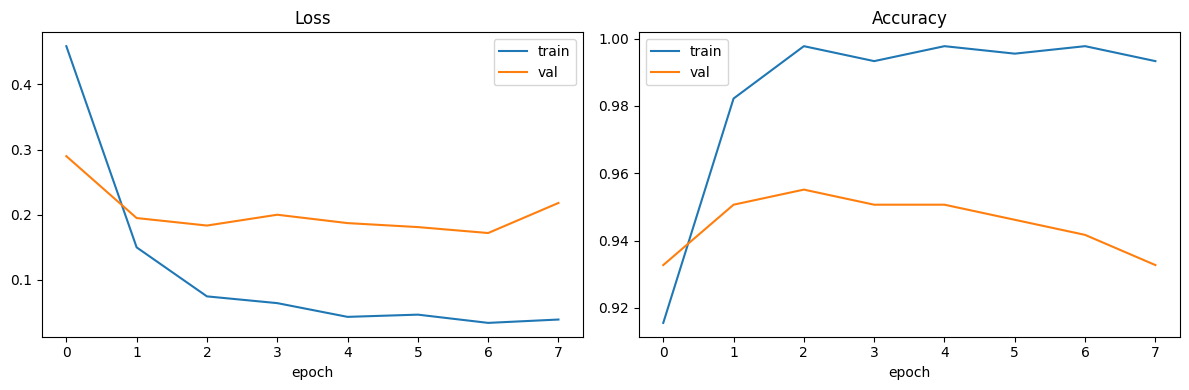

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_ft["train_loss"], label="train"); ax1.plot(history_ft["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(history_ft["train_acc"], label="train"); ax2.plot(history_ft["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()

#### Final model evaluation
This cell performs our final model evaluation on the test set.

In [34]:
model.load_state_dict(best_state)   # the epoch-3 fine-tuned weights
test_loss, test_acc = evaluate(model, test_loader)
print(f"TEST accuracy: {test_acc:.1%}  (loss {test_loss:.3f})")

TEST accuracy: 96.9%  (loss 0.154)


#### Collecting every prediction

In [35]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for images, labels in loader:
        logits = model(images.to(device))
        all_probs.append(logits.softmax(dim=1).cpu())
        all_labels.append(labels)
    probs = torch.cat(all_probs)
    return probs, probs.argmax(1), torch.cat(all_labels)

probs, preds, labels = get_predictions(model, test_loader)

#### Confusion Matrix
This snippet performs detailed error diagnostics on our test predictions. We calculate a 15×15 confusion matrix and display it as a heatmap with cleaned species labels, allowing us to see exactly which bird species are correctly identified along the diagonal and spot any pair-wise confusions. Finally, classification_report gives us precision, recall, and F1-score for each species, helping us verify that the model performs consistently across all 15 classes rather than just performing well on a select few.

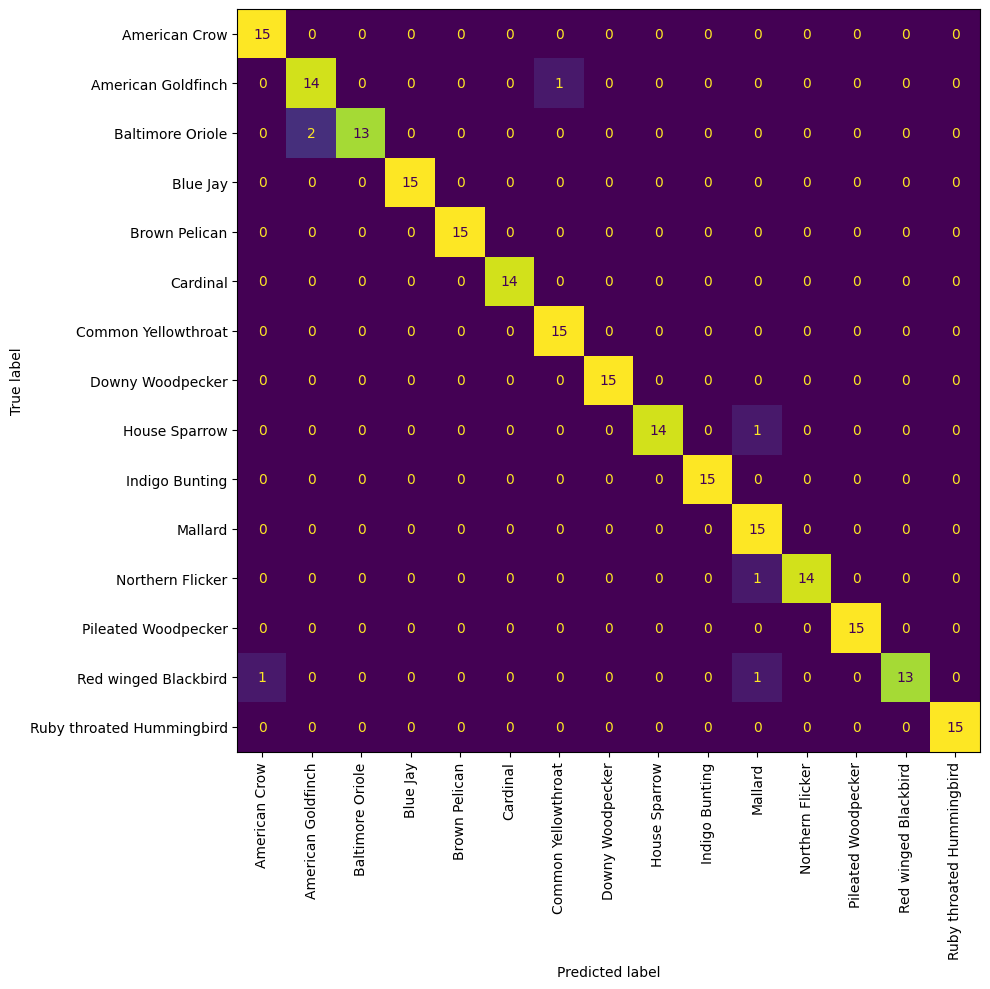

                           precision    recall  f1-score   support

            American_Crow      0.938     1.000     0.968        15
       American_Goldfinch      0.875     0.933     0.903        15
         Baltimore_Oriole      1.000     0.867     0.929        15
                 Blue_Jay      1.000     1.000     1.000        15
            Brown_Pelican      1.000     1.000     1.000        15
                 Cardinal      1.000     1.000     1.000        14
      Common_Yellowthroat      0.938     1.000     0.968        15
         Downy_Woodpecker      1.000     1.000     1.000        15
            House_Sparrow      1.000     0.933     0.966        15
           Indigo_Bunting      1.000     1.000     1.000        15
                  Mallard      0.833     1.000     0.909        15
         Northern_Flicker      1.000     0.933     0.966        15
      Pileated_Woodpecker      1.000     1.000     1.000        15
     Red_winged_Blackbird      1.000     0.867     0.929     

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(labels, preds)
pretty = [c.replace("_", " ") for c in class_names]
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm, display_labels=pretty).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.tight_layout(); plt.show()

print(classification_report(labels, preds, target_names=class_names, digits=3))

#### Checking the mistakes
This snippet performs visual error analysis on our test set. It identifies the indices of all misclassified images by comparing preds against labels, then plots the first eight failure cases in a 2x4 grid using PIL and Matplotlib. For each photo, it displays the original image along with its true class, predicted class, and prediction confidence, allowing us to visually inspect whether mistakes were driven by occlusions, extreme lighting, or fine-grained morphological similarities between species.

7 mistakes out of 224 test images


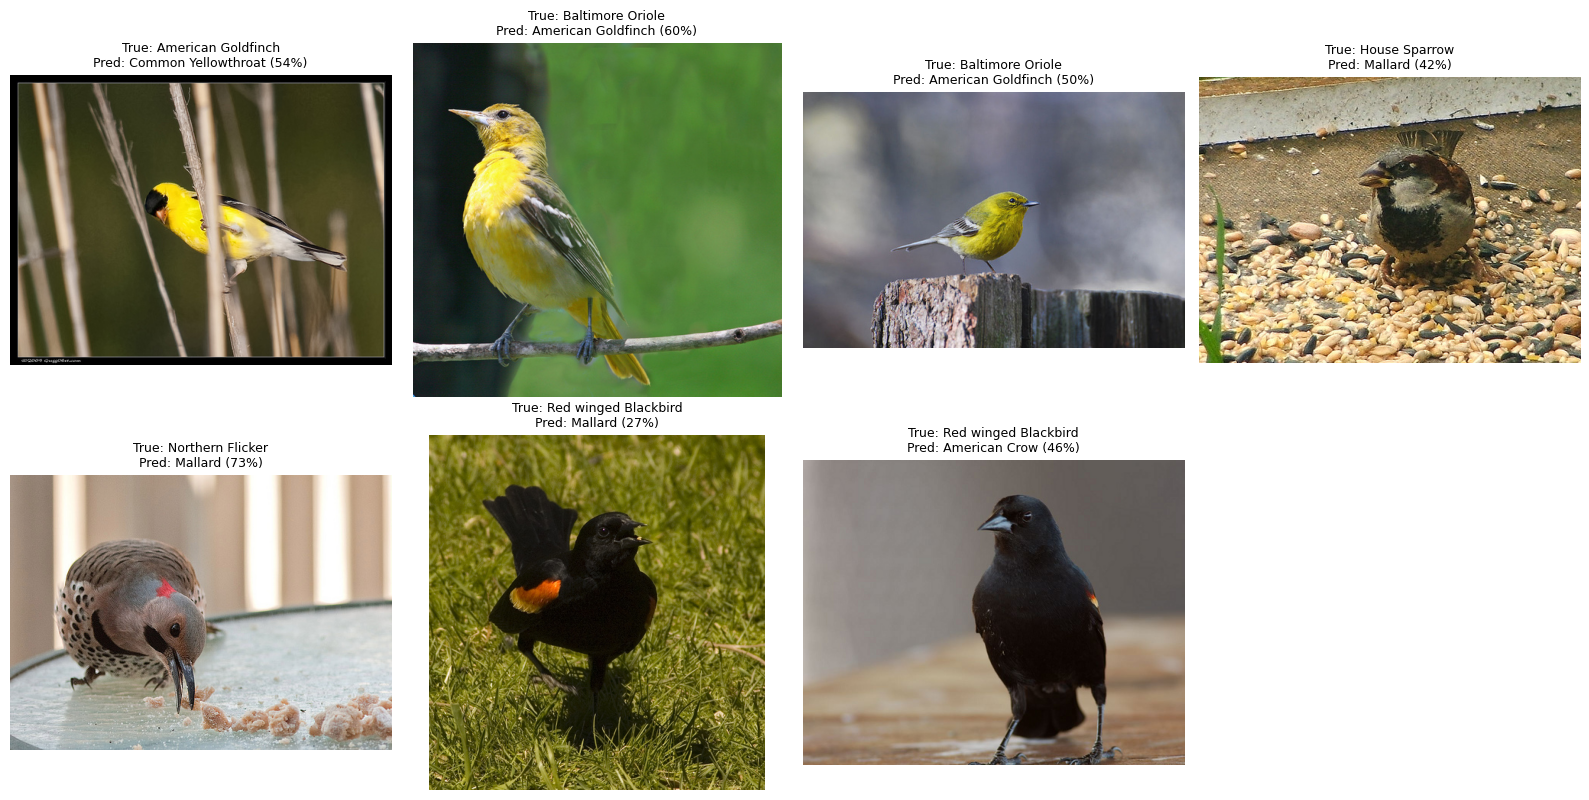

In [39]:
wrong = (preds != labels).nonzero().flatten().tolist()
print(f"{len(wrong)} mistakes out of {len(labels)} test images")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, i in zip(axes.flat, wrong[:8]):
    path, _ = test_ds.samples[i]
    ax.imshow(Image.open(path))
    ax.set_title(f"True: {pretty[labels[i]]}\nPred: {pretty[preds[i]]} ({probs[i].max():.0%})",
                 fontsize=9)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout(); plt.show()

#### Finding the top 3 predictors on any photo

Saving blue jay.jpg to blue jay (3).jpg


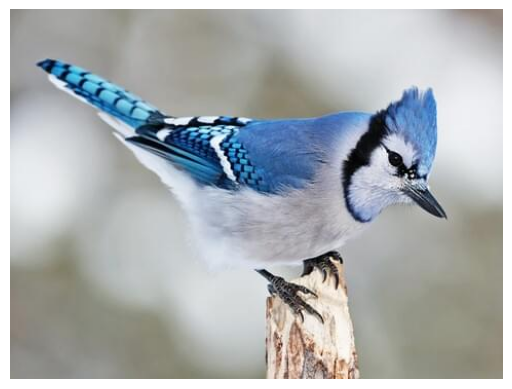

Blue Jay                     94.6%
Downy Woodpecker             5.1%
Mallard                      0.1%


In [49]:
from google.colab import files

def predict_top3(img):
    x = eval_tfms(img.convert("RGB")).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        p = model(x).softmax(dim=1)[0]
    top = p.topk(3)
    return [(pretty[i], v.item()) for v, i in zip(top.values, top.indices)]

uploaded = files.upload()                      # pick a bird photo from your computer
for name in uploaded:
    img = Image.open(name)
    plt.imshow(img); plt.axis("off"); plt.show()
    for species, conf in predict_top3(img):
        print(f"{species:28s} {conf:.1%}")

#### Export model.pth
free Hugging Face Spaces run on CPU only. Weights saved from GPU memory are tagged as GPU tensors, and loading them on a machine without a GPU causes errors unless you handle it specially. Saving CPU copies avoids that problem.

In [52]:
cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save({"state_dict": cpu_state, "class_names": class_names, "arch": "resnet18"},
           SAVE_DIR / "model.pth")
print("Exported:", SAVE_DIR / "model.pth")

Exported: /content/drive/MyDrive/neural_nightingale/model.pth


#### Confidence calibration
This evaluates the model's confidence calibration on the validation set. By isolating the maximum predicted probabilities, we compute percentiles for correct predictions to see how high confidence stays when the model succeeds, and inspect the confidence scores for misclassifications. Comparing these two distributions lets us identify an empirical confidence threshold (such as 60%) to reject uncertain or out-of-distribution inputs in production before serving predictions to users

In [51]:
val_probs, val_preds, val_labels = get_predictions(model, val_loader)
conf = val_probs.max(dim=1).values
correct = val_preds == val_labels

print("Confidence on CORRECT validation predictions:")
for q in [0.01, 0.05, 0.10, 0.25, 0.50]:
    print(f"  {q:>4.0%} percentile: {conf[correct].quantile(q):.1%}")

print("\nConfidence on WRONG validation predictions:",
      sorted(f"{c:.1%}" for c in conf[~correct]))

Confidence on CORRECT validation predictions:
    1% percentile: 46.2%
    5% percentile: 62.2%
   10% percentile: 71.3%
   25% percentile: 88.9%
   50% percentile: 97.3%

Confidence on WRONG validation predictions: ['15.2%', '35.1%', '42.5%', '47.3%', '52.9%', '53.2%', '53.7%', '58.3%', '59.3%', '85.8%']


#### Building the app and deployment

In [53]:
!pip install -q gradio
!cp /content/drive/MyDrive/neural_nightingale/model.pth .

In [54]:
%%writefile app.py
import torch
import torch.nn as nn
from torchvision import models, transforms
import gradio as gr

# ---------- 1. Rebuild the empty architecture, then load our trained weights ----------
checkpoint = torch.load("model.pth", map_location="cpu")
class_names = checkpoint["class_names"]
pretty = [c.replace("_", " ") for c in class_names]

model = models.resnet18(weights=None)                          # structure only, no download
model.fc = nn.Linear(model.fc.in_features, len(class_names))   # same 15-output head as training
model.load_state_dict(checkpoint["state_dict"])
model.eval()

# ---------- 2. EXACTLY the same preprocessing as validation/test ----------
eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

CONFIDENCE_THRESHOLD = 0.80

# ---------- 3. The prediction function Gradio calls on every upload ----------
def predict(img):
    if img is None:
        return {}, "Upload a photo to get started."
    x = eval_tfms(img.convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        probs = model(x).softmax(dim=1)[0]
    top = probs.topk(3)
    results = {pretty[i]: v.item() for v, i in zip(top.values, top.indices)}

    if top.values[0] < CONFIDENCE_THRESHOLD:
        note = ("**Not confident.** This may not be one of the 15 species I know, "
                "or the bird may be hard to see. Treat these guesses with caution.")
    else:
        note = f"Looks like a **{pretty[top.indices[0]]}**."
    return results, note

# ---------- 4. The web interface ----------
species_list = ", ".join(pretty)
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Bird photo"),
    outputs=[gr.Label(num_top_classes=3, label="Top 3 predictions"), gr.Markdown()],
    title="Neural Nightingale",
    description=(
        "A ResNet-18 fine-tuned on 15 North American bird species "
        "(~97% test accuracy). Upload a photo to see the top 3 guesses.\n\n"
        f"**Species it knows:** {species_list}.\n\n"
        "It can only choose among these 15, so any other bird (or a car!) "
        "will still get labeled as one of them. "
        "Trained on the CUB-200-2011 dataset (Caltech/UCSD), for educational use."
    ),
)

demo.launch()

Writing app.py


In [55]:
%run app.py

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://97d1a88131ffcc6c18.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<Figure size 640x480 with 0 Axes>

In [56]:
%%writefile requirements.txt
--extra-index-url https://download.pytorch.org/whl/cpu
torch
torchvision

Writing requirements.txt


In [1]:
import json, torch, torch.nn as nn
from pathlib import Path
from torchvision import models, transforms
from PIL import Image

# Load the checkpoint (local copy if it exists, otherwise from Drive)
path = Path("model.pth")
if not path.exists():
    from google.colab import drive
    drive.mount("/content/drive")
    path = Path("/content/drive/MyDrive/neural_nightingale/model.pth")

ckpt = torch.load(path, map_location="cpu")
pretty = [c.replace("_", " ") for c in ckpt["class_names"]]

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(pretty))
model.load_state_dict(ckpt["state_dict"])
model.eval()

# Export to ONNX and save the class names
torch.onnx.export(model, torch.randn(1, 3, 224, 224), "model.onnx",
                  input_names=["image"], output_names=["logits"])
with open("class_names.json", "w") as f:
    json.dump(pretty, f)

# Verify the ONNX model matches PyTorch on a real photo
import onnxruntime as ort
eval_tfms = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
x = eval_tfms(Image.open("blue jay (2).jpg").convert("RGB")).unsqueeze(0)
with torch.no_grad():
    torch_logits = model(x).numpy()
onnx_logits = ort.InferenceSession("model.onnx").run(None, {"image": x.numpy()})[0]
print("Max difference:", abs(torch_logits - onnx_logits).max())
print("ONNX top prediction:", pretty[onnx_logits.argmax()])

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Max difference: 1.9073486e-06
ONNX top prediction: Blue Jay
